# Counterfactuals with simple estimators

First step, importing packages.

In [1]:
import sys
# Add the parent directory to the path to be able to import whatif
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from openml.datasets import get_dataset
from whatif import Dataset
from whatif.uplift import EasyEnsemble, TLearnerWrapper, calibrate_score
from whatif.cf import frechet_bounds, uplift_bounds, Independence, Simplex4DAxes


/home/tverhels/Dropbox/Documents/PhD/code/What-If/examples/../whatif/cf/bivariate_beta.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


Let us load the uplift dataset with Orange customer data from OpenML.

In [2]:
dataset = get_dataset("churn-uplift-orange").get_data()[0]

/home/tverhels/anaconda3/lib/python3.9/site-packages/openml/datasets/functions.py:438: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


And convert it to a Dataset object to train an uplift model on it

In [3]:
dataset = Dataset(
    X = dataset.drop(["y", "t"], axis=1),
    y = (dataset.y == 1).to_numpy(),
    t = (dataset.t == 1).to_numpy()
)
dataset.X = pd.get_dummies(dataset.X).to_numpy().astype("float32")

Let us train an uplift model and predict the uplift scores $S_0(x)$ and $S_1(x)$. In practice you would want to divide the dataset into a training and a test set, however for the purpose of this example, this does not matter. We use the EasyEnsemble methodology to mitigate class imbalance.

In [4]:
model = EasyEnsemble(
    TLearnerWrapper(RandomForestClassifier(n_estimators=100)),
    n_folds=10
)
model.fit(dataset)
pred = model.predict(dataset)
S_0 = pred["control"]
S_1 = pred["target"]

Since the scores $S_0(x)$ and $S_1(x)$ are biased due to the class balancing with EasyEnsemble, we need to re-calibrate them. We do this using a calibration formula that ensure that the mean predicted score is equal to the average probability of the outcome to be positive: $$\mathbb E[S_0(x)] = P(\mathbf{y}_0=1).$$

In [5]:
P_y_0 = np.mean(dataset.y[~dataset.t])
P_y_1 = np.mean(dataset.y[dataset.t])

print("Means before calibration: {:.1%}, {:.1%}".format(np.mean(S_0), np.mean(S_1)))
print("Target means:  {:.1%}, {:.1%}".format(P_y_0, P_y_1))
S_0 = calibrate_score(calibrate_score(S_0, P_y_0), P_y_0)
S_1 = calibrate_score(calibrate_score(S_1, P_y_1), P_y_1)
print("Means after calibration: {:.1%}, {:.1%}".format(np.mean(S_0), np.mean(S_1)))

Means before calibration: 43.6%, 47.0%
Target means:  3.6%, 3.4%
Means after calibration: 3.6%, 3.4%


We can now execute the basic counterfactual estimators: we want to estimate the probability distribution

\begin{align}
    \alpha &= P(\mathbf y_0=0, \mathbf y_1=0) \\
    \beta  &= P(\mathbf y_0=1, \mathbf y_1=0) \\
    \gamma &= P(\mathbf y_0=0, \mathbf y_1=1) \\
    \delta &= P(\mathbf y_0=1, \mathbf y_1=1).
\end{align}

The first one is the Fréchet bounds, $$\max\{0, P(A)+P(B)-1\}\le P(A,B)\le\min\{P(A),P(B)\}.$$

In [6]:
frechet_lb, frechet_ub = frechet_bounds(np.mean(S_0), np.mean(S_1))

def print_bounds(lb, ub):
    for i, letter in enumerate(["alpha", "beta ", "gamma", "delta"]):
        print("{:5.1%} <= {} <= {:5.1%}".format(lb[i], letter, ub[i]))
        
print_bounds(frechet_lb, frechet_ub)

93.0% <= alpha <= 96.4%
 0.3% <= beta  <=  3.6%
 0.0% <= gamma <=  3.4%
 0.0% <= delta <=  3.4%


Then, our new uplift bounds,
$$
\mathbb E_{\mathbf x}[\max\{P(A \mid\mathbf x) + P(B \mid\mathbf x) - 1\}] \le P(A, B) \le\mathbb E_{\mathbf x}[\min\{P(A\mid\mathbf x), P(B,\mid\mathbf x)\}].
$$

In [7]:
uplift_lb, uplift_ub = uplift_bounds(S_0, S_1)
print_bounds(uplift_lb, uplift_ub)

93.0% <= alpha <= 95.7%
 0.9% <= beta  <=  3.6%
 0.6% <= gamma <=  3.4%
 0.0% <= delta <=  2.8%


And finally, our new estimator based on conditional independence,
$$
P(A,B)\approx\mathbb E_{\mathbf x}[P(A\mid\mathbf x)P(B\mid\mathbf x)].
$$

In [8]:
ind_model = Independence()
ind_model.fit(S_0, S_1)
ind_pred = ind_model.population_cf()
for i, letter in enumerate(["alpha", "beta ", "gamma", "delta"]):
    print("{} ~ {:5.1%}".format(letter, ind_pred[i]))

alpha ~ 93.1%
beta  ~  3.5%
gamma ~  3.2%
delta ~  0.1%


Let us plot the resulting estimators on a custom matplotlib Axes.

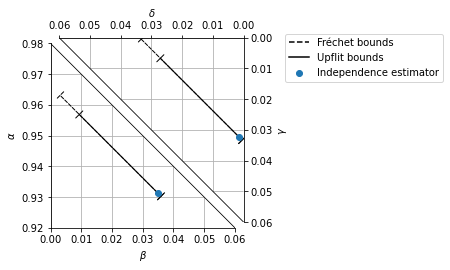

In [9]:
fig = plt.figure()
ax = Simplex4DAxes(fig)
ax.set_ylabel("$\\alpha$")
ax.set_xlabel("$\\beta$")
ax.set_zlabel("$\\delta$")
ax.set_wlabel("$\\gamma$")
ax.set_xlim(0, 0.06)
ax.set_ylim(0.92, 0.98)
ax.set_zlim(0, 0.06)
ax.set_wlim(0, 0.06)

ax.plot_bounds(frechet_lb, frechet_ub, linestyle="dashed", color="black", label="Fréchet bounds")
ax.plot_bounds(uplift_lb, uplift_ub, color="black", label="Upflit bounds")
ax.scatter(ind_pred[1], ind_pred[0], ind_pred[3], ind_pred[2], label="Independence estimator")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.2, 1.05)
)

plt.show()